In [51]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df['dm']
X=df.drop(columns=['dm'])

In [52]:
X.shape

(4325, 29)

In [53]:
y.shape

(4325,)

In [54]:
y.value_counts()

dm
0    2227
1    1402
2     696
Name: count, dtype: int64

In [55]:
import torch.cuda
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


True
NVIDIA GeForce RTX 4070 SUPER


In [56]:
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import root_mean_squared_error,r2_score

from sklearn.pipeline import Pipeline
from tabpfn import TabPFNClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(y.value_counts())

scalar=StandardScaler()
X_train_pr=scalar.fit_transform(X_train)
X_test_pr=scalar.transform(X_test)

X_trainp = pd.DataFrame(X_train_pr, columns=X_train.columns, index=X_train.index)
X_testp = pd.DataFrame(X_test_pr, columns=X_test.columns, index=X_test.index)


    # 모델 정의
preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ['age', 'chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi', 'wk_smk',
            'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk', 'wk_sleep', 'glu', 'hba1c',
            'stress', 'wk_break', 'wk_lunch', 'wk_dinner', 'wk_veg1', 'wk_veg2','wk_fruit',
            'edu','income'
            ]
),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ['sex','job',])
        ]
    )

    # ============================================
    # 3. TabPFN v2 모델 정의
    # ============================================
model = TabPFNClassifier(
        device="auto",  # GPU 사용 가능 시 "cuda"
    )

    # ============================================
    # 4. Pipeline 구성
    # ============================================
pipe = Pipeline([
        ("preprocess", preprocess),
        ("tabpfn", model)
    ])

    # ============================================
    # 5. 모델 학습
    # ============================================
pipe.fit(X_trainp, y_train)


# 테스트셋 예측 및 평가
y_pred = pipe.predict(X_testp)    #이거 하면 [0.3,0.6,0.1]와 같이 prob 결과를 산출한 후 가장 값이 큰 인덱스를 y_pred에 넣는다. 
y_proba = pipe.predict_proba(X_testp)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred,average='weighted')
rec=recall_score(y_test,y_pred,average='weighted')
f1=f1_score(y_test,y_pred,average='weighted')

r2=r2_score(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 score: {f1:.4f}")
#print(f"r2:{r2}, rmse:{rmse}")

dm
0    2227
1    1402
2     696
Name: count, dtype: int64
Accuracy: 0.9514, Precision: 0.9518, Recall: 0.9514, F1 score: 0.9504


In [57]:
y_test.dtypes

dtype('int64')

c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


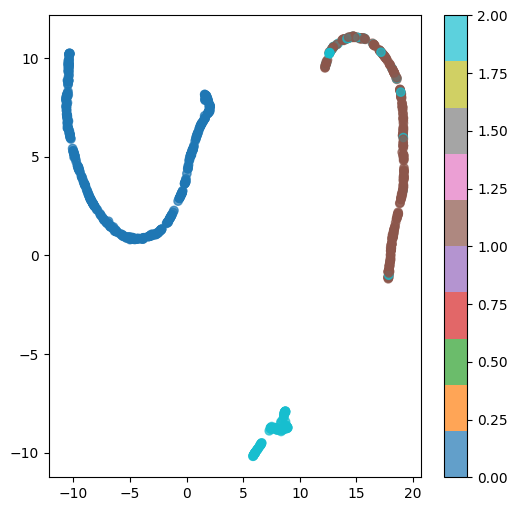

In [58]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

outputs=pipe.predict_proba(X_testp).astype(np.float32)
labels = y_test.astype(float).to_numpy()

reducer = umap.UMAP(n_components=2, random_state=42,n_neighbors=70)
X_umap = reducer.fit_transform(outputs)

# 시각화 (예: UMAP)
plt.figure(figsize=(6,6))
plt.scatter(X_umap[:,0], X_umap[:,1],c=labels, cmap='tab10', alpha=0.7)
plt.colorbar()
plt.show()

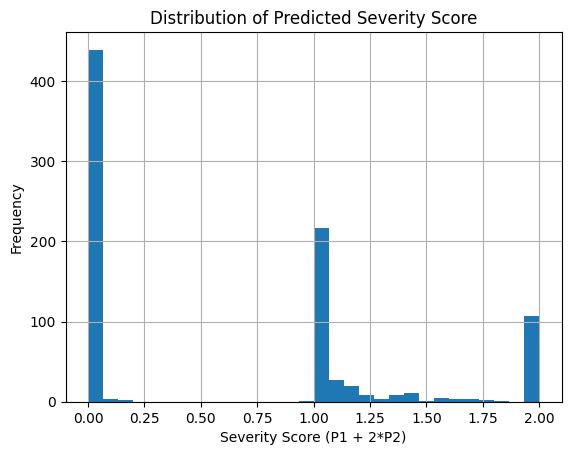

In [59]:
import matplotlib.pyplot as plt

y_score = y_proba[:, 1] + 2 * y_proba[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()